# Properties cold calling list with score

# Project Overview

## Objective

The goal of this project is to identify **Single Family Homes** in Anne Arundel County, Maryland, that have a higher likelihood of being sold.

## Data Processing

* Retrieved property records from the county's ArcGIS REST API.
* Filtered the dataset to include only **Single Family Homes** (SFD and SFA).
* Standardized structure type values to ensure consistency across the dataset.
* Renamed and formatted fields to improve readability and simplify analysis.

## Analysis

The analysis focuses on identifying properties that are more likely to be listed for sale based on historical ownership data.

One of the primary indicators is the **Last Transfer Date**. Properties that have not changed ownership for **3–4 years or more** are considered more likely to be sold compared to recently transferred properties.

Additional analysis includes:

* Identifying the cities with the highest concentration of eligible properties.
* Determining geographic areas where these properties are clustered.
* Summarizing the distribution of potential opportunities across the county.

## Expected Outcome

The final dataset provides a filtered list of Single Family Homes along with supporting information that can be used for lead generation, market analysis, or further predictive modeling.


## Project steps
1- Extracting the data from public county gis

2- Cleaning the data 

In [1]:
import requests
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import os

In [5]:
import pandas as pd

df = pd.read_csv("MD_Anne_Arnuld_GDSC.csv")
print(df.shape)

(215467, 41)


C:\Users\ii\AppData\Local\Temp\ipykernel_5148\473927870.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MD_Anne_Arnuld_GDSC.csv")


In [4]:
BASE_URL = "https://gis.aacounty.org/arcgis/rest/services/OpenData/Structure_OpenData/MapServer/0/query"

# Number of records retrieved in each  request
BATCH_SIZE = 1000

# Starting point for pagination
offset = 0

# Output CSV file
csv_file = "MD_Anne_Arnuld_GDSC.csv"

# Continue requesting data until returns no more records
while True:
    params = {
        "f": "json",
        "where": "1=1",
        "outFields": "*",
        "resultRecordCount": BATCH_SIZE,
        "resultOffset": offset,
        "orderByFields": "OBJECTID ASC"
    }
    
# Sending request 
    response = requests.get(BASE_URL, params=params)
    data = response.json()

# Extract the list of features from the response
    features = data.get("features", [])
    
# Stop the loop when no more records are available
    if not features:
        print("No more data to fetch.")
        break
        
# Convert feature attributes into a DataFrame       
    df = pd.json_normalize([f["attributes"] for f in features])
    
# Append the current batch to the CSV file
# Write the header only when the file is created for the first time
    df.to_csv(
        csv_file,
        mode="a",
        index=False,
        header=not os.path.exists(csv_file),
        encoding="utf-8-sig"
    )
    print(f"Added {len(df)} records.")
    
   # Move to the next batch
    offset += BATCH_SIZE

print(f"All data saved to {csv_file}")

Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.
Added 1000 records.


In [6]:
# saving DataFrame as csv with low_memory = Flase to handle the mixes datatypes columns
df = pd.read_csv("MD_Anne_Arnuld_GDSC.csv", low_memory = False)

In [7]:
# to display all the columns without limit
pd.set_option('display.max_columns', None)
df.head(3)

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,last_edi_1
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{F789E2B0-0103-484A-A90D-7CF81022BF3E},,1.224806e+12,GIS_AnneArundel,1741824000000
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{EDEF7DBF-128B-473E-A28E-751AEB32D0B2},,1.224806e+12,pzmagl22,1740441600000
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{19767F3B-BE84-416D-AA1D-82F7690A6BA7},,1.224806e+12,ITMAGL23,1595808000000


In [8]:
# Changing the data type for these columns from ms to date time
df["created_da"] = pd.to_datetime(df["created_da"], unit="ms", errors="coerce")
df["last_edi_1"] = pd.to_datetime(df["last_edi_1"], unit="ms", errors="coerce")

In [9]:
# renaming the column with more Descriptive Name
df.rename(columns={"last_edi_1": "Transfer_Date"}, inplace=True)

In [10]:
# to be sure the date time type changed and the column name
df.head()

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{F789E2B0-0103-484A-A90D-7CF81022BF3E},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{EDEF7DBF-128B-473E-A28E-751AEB32D0B2},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{19767F3B-BE84-416D-AA1D-82F7690A6BA7},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,0,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{6EB2A48F-9403-4835-ABB6-F4CBC0034711},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,0,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{05272E89-016B-46F5-A21C-E28CA8F2E052},,2008-10-24,ITMAGL23,2020-07-27


In [11]:
# to make cleaning data easier and know what we need and what we do not
columns = ["BLDG_CODE","ST_SUFFIXD","PT_TYPE","UNIT_ADDR", "UNIT_TYPE", "UNITNUM","UNIT_ADDR","SUB_ADDR","BUS_NAME","ACCESS_X","STRUC_TYPE"]

for col in columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== BLDG_CODE ===
BLDG_CODE
RESIDENTIAL            195436
COMMERCIAL               7420
PLANNED                  4656
GOVERNMENT               2825
LAND                     2164
OPEN SPACE               1035
ASSET                     629
PLACE OF WORSHIP          384
EDUCATIONAL               203
RECREATIONAL AREA         196
OTHER INSTITUTIONAL       186
MEDICAL                    94
PARKING                    64
MIXED USE                  49
FIRE STATION               40
POST OFFICE                30
LIBRARY                    14
STORAGE                    13
AIRPORT                    12
CORRECTIONAL                9
POLICE STATION              4
NO STRUCTURE                4
Name: count, dtype: int64

=== ST_SUFFIXD ===
ST_SUFFIXD
      209606
W       1465
E       1290
S        915
N        881
SW       545
SE       268
NE       266
NW       231
Name: count, dtype: int64

=== PT_TYPE ===
PT_TYPE
ADDRESS    215434
COMPLEX        33
Name: count, dtype: int64

=== UNIT_ADDR ===
UNIT_

In [12]:
# we need only Adresses And RESIDENTIAL Code 
df = df[df["PT_TYPE"] == "ADDRESS"]
df = df[df["BLDG_CODE"] == "RESIDENTIAL"]

In [13]:
# saving STRUC_TYPE with only single family homes
df = df[
    df["STRUC_TYPE"].isin([
        "SFD",
        "SFA",
        "SINGLE FAMILY DWELLING",
        "SINGLE FAMILY ATTACHED"
    ])
]

In [14]:
# Replace verbose structure type names with standardized abbreviations
# to keep the dataset consistent for filtering and analysis.
df["STRUC_TYPE"] = df["STRUC_TYPE"].replace({
    "SINGLE FAMILY DWELLING": "SFD",
    "SINGLE FAMILY ATTACHED": "SFA"
})

- Phase 3: Exploratory Data Analysis (EDA)

* Inspected the dataset structure by listing all available columns and calculating the number of unique values in each feature.

* Generated descriptive statistics for the street number column and examined the distributions of numerical features using histograms and density plots.

* Analyzed the frequency distribution of important variables, including floor numbers, ZIP codes, and restricted address records.

* Identified the ten most frequent ZIP codes and visualized their record counts using a bar chart.

* Converted the creation date into a proper DateTime format, extracted the year and month, and analyzed the yearly distribution of created address records.

* Converted the transfer date into a DateTime format and visualized the yearly trend of transferred records.

* Examined the geographical distribution of the address points using POINT_X and POINT_Y coordinates and generated descriptive statistics for the spatial coordinate columns.

* Verified the dataset quality by checking for duplicate records and remaining missing values.

* Detected potential outliers across all numerical features using boxplots.

* Analyzed the relationships between numerical variables by creating a correlation heatmap.

In [15]:
df.tail()

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
215271,215272,70014992,0,ADDRESS,"2665 EVERGREEN RD, 21113",2665,,,EVERGREEN,RD,,,PLAT/SITE PLAN,ODENTON,,,0,,,,N,21113,10784,,1,0.0,0.0,RESIDENTIAL,,0,RD,2665 EVERGREEN RD,"ADDED AAID, OPZ ADDED PER I&P",1.396441e+06,498965.443594,SFD,{FD78DC16-9986-47E1-8B1B-EA7C67E0BC55},PZCLOU23,2026-03-25,GIS_AnneArundel,2026-04-14
215281,215282,70015025,0,ADDRESS,"3506 ROCKWAY AVE, 21403",3506,,,ROCKWAY,AVE,,,INFERRED FROM OTHER SOURCES,ANNAPOLIS,,,0,,,,N,21403,10129,N,1,0.0,0.0,RESIDENTIAL,,0,AV,3506 ROCKWAY AV,ADDED PER PERMIT,1.464490e+06,456349.227317,SFD,{D9FE4657-5BBD-41A6-8C14-76CFF0442E3A},GIS_AnneArundel,2026-04-08,GIS_AnneArundel,2026-04-08
215326,215327,70015157,0,ADDRESS,"4270 HAWTHORNE FARMS RD, 20776",4270,,,HAWTHORNE FARMS,RD,,,PLAT/SITE PLAN,HARWOOD,,,0,,,,N,20776,21117,,1,0.0,0.0,RESIDENTIAL,,0,RD,4270 HAWTHORNE FARMS RD,"ADDED AAID, OPZ ADDED PER I&P TO MATCH SDAT",1.413320e+06,441688.054212,SFD,{DD24DE1D-0A1A-4C1C-A38F-069F98904FA0},PZCLOU23,2026-05-15,GIS_AnneArundel,2026-06-15
215340,215341,70015403,0,ADDRESS,"1005 MOUNT HOLLY DR, 21409",1005,,,MOUNT HOLLY,DR,,,PLAT/SITE PLAN,ANNAPOLIS,,,0,,,,N,21409,22570,,1,0.0,0.0,RESIDENTIAL,,0,DR,1005 MOUNT HOLLY DR,"ADDED AAID, OPZ ADDED PER I&P",1.470528e+06,501451.318872,SFD,{001A6244-87DF-41BD-83F6-52502582FF35},PZCLOU23,2026-06-11,GIS_AnneArundel,2026-06-15
215461,215462,70015556,0,ADDRESS,"200 HOLY CROSS RD, 21225",200,,,HOLY CROSS,RD,,,PERSONALLY VERIFIED,BROOKLYN,,,0,,,,N,21225,0,,1,0.0,0.0,RESIDENTIAL,,0,,,OPZ ADDED PER HD,1.421134e+06,562710.866300,SFD,{F495835D-A42D-46E2-8B83-6BCAAFDC8338},PZCLOU23,2026-07-01,PZCLOU23,2026-07-01


In [16]:
df.head(10)

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{F789E2B0-0103-484A-A90D-7CF81022BF3E},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{EDEF7DBF-128B-473E-A28E-751AEB32D0B2},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{19767F3B-BE84-416D-AA1D-82F7690A6BA7},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,0,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{6EB2A48F-9403-4835-ABB6-F4CBC0034711},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,0,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{05272E89-016B-46F5-A21C-E28CA8F2E052},,2008-10-24,ITMAGL23,2020-07-27
5,6,6001720,0,ADDRESS,"6065 WELCH AVE, 20751",6065,,,WELCH,AVE,,,NOT VERIFIED,DEALE,,,0,,,,N,20751,13248,N,1,0.0,0.0,RESIDENTIAL,,0,AV,6065 WELCH AV,,1.439079e+06,402795.775369,SFD,{F98AC702-9D6A-44BB-A157-813912E6AC40},,2008-10-24,ITMAGL23,2020-07-27
6,7,6001721,0,ADDRESS,"615 E MARSHALL AVE, 20751",615,,E,MARSHALL,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,2350,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 E MARSHALL AV,ABBREVIATED PREFIX DIRECTIONAL,1.439303e+06,402847.952758,SFD,{A06A5C4E-8B26-4576-B162-BE727FCC7ECF},,2008-10-24,ITMAGL23,2020-07-27
7,8,6001725,0,ADDRESS,"616 E MARSHALL AVE, 20751",616,,E,MARSHALL,AVE,,,INFERRED FROM OTHER SOURCES,DEALE,,,0,,,,N,20751,2350,N,1,0.0,0.0,RESIDENTIAL,,0,AV,616 E MARSHALL AV,ABBREVIATED PREFIX DIRECTIONAL,1.439451e+06,402905.190505,SFD,{B0A39B2F-3A0E-4D2A-873F-8E03DD415CB4},,2008-10-24,ITMAGL23,2020-07-27
8,9,6001728,0,ADDRESS,"6164 DRUM POINT RD, 20751",6164,,,DRUM POINT,RD,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,30434,N,1,0.0,0.0,RESIDENTIAL,,0,RD,6164 DRUM POINT RD,,1.437674e+06,403045.150527,SFD,{DBF73DEF-772A-4944-BDD1-565EAB2ED52D},,2008-10-24,ITMAGL23,2020-07-27
9,10,6001745,0,ADDRESS,"6040 MELBOURNE AVE, 20751",6040,,,MELBOURNE,AVE,,,INFERRED FROM OTHER SOURCES,DEALE,,,0,,,,N,20751,29122,N,1,0.0,0.0,RESIDENTIAL,,0,AV,6040 MELBOURNE AV,,1.440205e+06,403211.295864,SFD,{8991A5FB-C0C1-4117-B3B7-BC2C73A8DBAF},,2008-10-24,ITMAGL23,2020-07-27


In [17]:
df.sample(10)

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
202139,202140,9906489,0,ADDRESS,"232 CEDAR HILL LN, 21225",232,,,CEDAR HILL,LN,,,,BROOKLYN,,,0,,,,N,21225,21660,N,1,0.0,0.0,RESIDENTIAL,,0,LN,232 CEDAR HILL LN,UPDATED BLDG_CODE,1.423524e+06,563311.365427,SFD,{1BDE9570-21F7-4FAB-9F82-39F8731AFA58},,2017-05-12,ITMAGL23,2019-09-27
200972,200973,66698607,0,ADDRESS,"2271 KELSTON PL, 21113",2271,,,KELSTON,PL,,,,ODENTON,,,0,,,,N,21113,52935,N,1,0.0,0.0,RESIDENTIAL,,0,PL,2271 KELSTON PL,"UPDATED BLDG_CODE PER COO, UPDATED AAID-UPDATE...",1.395919e+06,521328.090142,SFA,{83EB9D07-A7CB-4B9B-8AAF-62A107F3882B},,2016-11-16,ITVKLI20,2021-11-03
84158,84159,1083382,0,ADDRESS,"8089 CATHERINE AVE, 21122",8089,,,CATHERINE,AVE,,,PHYSICALLY VERIFIED IN FIELD,PASADENA,,,0,,,,N,21122,5469,N,1,0.0,0.0,RESIDENTIAL,,0,AV,8089 CATHERINE AV,,1.440898e+06,531811.863137,SFD,{6CCBA8DF-32C0-4859-A744-62CD05A852DC},,2008-11-24,ITVMAN00,2018-09-11
147804,147805,1112654,0,ADDRESS,"308 GREEN DR, 21122",308,,,GREEN,DR,,,PHYSICALLY VERIFIED IN FIELD,PASADENA,,,0,,,,N,21122,4453,N,1,0.0,0.0,RESIDENTIAL,,0,DR,308 GREEN DR,,1.441621e+06,523190.419094,SFD,{C92886DB-C40F-4E5C-B86C-52E203BE2725},,2008-12-31,ITVMAN00,2018-09-11
3059,3060,6002913,0,ADDRESS,"5636 DARTMOUTH ST, 20733",5636,,,DARTMOUTH,ST,,,PHYSICALLY VERIFIED IN FIELD,CHURCHTON,,,0,,,,N,20733,15764,N,1,0.0,0.0,RESIDENTIAL,,0,ST,5636 DARTMOUTH ST,,1.449692e+06,412683.751985,SFD,{D4353B4F-FCE5-4E11-A380-F4E1E6FD53CD},,2008-12-13,ITVMAN00,2018-09-11
166012,166013,3003169,0,ADDRESS,"219H LOCKWOOD CT, 21403",219,H,,LOCKWOOD,CT,,,PHYSICALLY VERIFIED IN FIELD,ANNAPOLIS,,,0,,,,N,21403,9709,N,2,0.0,0.0,RESIDENTIAL,,0,CT,219H LOCKWOOD CT,,1.457403e+06,475443.373184,SFD,{0DFB914E-18CC-4DC5-B485-221D0967A51E},,2010-02-26,ITSINE23,2018-09-17
148206,148207,1113709,0,ADDRESS,"1480 THIES DR, 21122",1480,,,THIES,DR,,,PHYSICALLY VERIFIED IN FIELD,PASADENA,,,0,,,,N,21122,10968,N,1,0.0,0.0,RESIDENTIAL,,0,DR,1480 THIES DR,,1.465943e+06,521749.942972,SFD,{61DE757F-B846-4AC1-B7ED-06D87ED073CD},,2008-12-22,PZWILL21,2022-10-31
189410,189411,66686324,0,ADDRESS,"2214 JACOB WAY, 21054",2214,,,JACOB,WAY,,,PLAT/SITE PLAN,GAMBRILLS,,,0,,,,N,21054,43099,N,1,0.0,0.0,RESIDENTIAL,,0,WY,2214 JACOB WY,CHANGED FROM PLANNED TO LAND AS PER ADDED STRE...,1.408031e+06,495667.922958,SFD,{0DC652D2-8722-4B0F-A641-46949D24CF46},,2013-04-08,ITVMAN00,2018-09-11
96711,96712,1050021,0,ADDRESS,"6447 TRUSSEL OAK CT, 21090",6447,,,TRUSSEL OAK,CT,,,PHYSICALLY VERIFIED IN FIELD,LINTHICUM HEIGHTS,,,0,,,,N,21090,31301,N,1,0.0,0.0,RESIDENTIAL,,0,CT,6447 TRUSSEL OAK CT,,1.410381e+06,557891.329679,SFD,{856C44AB-8F9A-4AA4-AC56-C64AFA85FB53},,2009-01-05,ITVMAN00,2018-09-11
209885,209886,70004960,0,ADDRESS,"133 WOODGATE CIR, 21122",133,,,WOODGATE,CIR,,,PLAT/SITE PLAN,PASADENA,,,0,,,,N,21122,91021,,1,0.0,0.0,RESIDENTIAL,,0,CI,133 WOODGATE CI,CHGD BLDG_CODE,1.432048e+06,533039.792440,SFA,{2107C616-A784-4A41-BD29-CE2FF8A97754},PZWILL21,2021-12-14,itmill22,2024-12-11


In [18]:
df.describe()

,OBJECTID,ADDRPT_ID,MASTER_ID,FLOOR,ZIPCODE,AAID,BMC_ID,ACCESS_X,ACCESS_Y,RESTRICTED,POINT_X,POINT_Y,created_da,Transfer_Date
count,186316.000000,1.863160e+05,1.863160e+05,186316.0,186316.000000,186316.000000,186316.000000,1.863160e+05,186316.000000,186316.000000,1.863160e+05,186316.000000,186297,186316
mean,103441.071245,9.150098e+06,5.846957e+03,0.0,21115.348387,22371.752490,1.057891,6.949371e+01,24.865866,0.001288,1.427194e+06,510374.229245,2009-11-14 08:23:00.659914240,2019-02-12 11:20:29.420983808
min,1.000000,4.212200e+04,0.000000e+00,0.0,20701.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,1.361096e+06,381414.369313,2008-09-30 00:00:00,2018-09-06 00:00:00
25%,51500.750000,1.080453e+06,0.000000e+00,0.0,21060.000000,9700.000000,1.000000,0.000000e+00,0.000000,0.000000,1.407480e+06,488509.146265,2008-12-10 00:00:00,2018-09-11 00:00:00
50%,103090.500000,1.184854e+06,0.000000e+00,0.0,21113.000000,19608.000000,1.000000,0.000000e+00,0.000000,0.000000,1.428923e+06,519144.708026,2009-02-02 00:00:00,2018-09-11 00:00:00
75%,154058.250000,6.050495e+06,0.000000e+00,0.0,21144.000000,29546.000000,1.000000,0.000000e+00,0.000000,0.000000,1.447592e+06,536716.492600,2009-04-21 00:00:00,2018-09-11 00:00:00
max,215462.000000,7.001556e+07,7.000288e+07,0.0,21409.000000,907324.000000,2.000000,1.463883e+06,546247.806000,1.000000,1.482353e+06,571886.985087,2026-07-01 00:00:00,2026-07-09 00:00:00
std,59904.029837,1.844805e+07,4.334034e+05,0.0,163.043942,17642.329345,0.233538,9.999042e+03,3579.816944,0.035868,2.507175e+04,36270.075437,NaN,NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186316 entries, 0 to 215461
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OBJECTID       186316 non-null  int64         
 1   ADDRPT_ID      186316 non-null  int64         
 2   MASTER_ID      186316 non-null  int64         
 3   PT_TYPE        186316 non-null  object        
 4   FULL_ADDRE     186316 non-null  object        
 5   ST_NUMBER      186316 non-null  object        
 6   ST_NUMSUFF     186316 non-null  object        
 7   ST_PREFIXD     186316 non-null  object        
 8   ST_NAME        186316 non-null  object        
 9   ST_TYPE        186316 non-null  object        
 10  ST_SUFFIXD     186316 non-null  object        
 11  BLDG_NAME      186316 non-null  object        
 12  SOURCE         186316 non-null  object        
 13  CITY_NAME      186316 non-null  object        
 14  UNIT_TYPE      186316 non-null  object        
 15  UNITN

In [20]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
215271    False
215281    False
215326    False
215340    False
215461    False
Length: 186316, dtype: bool

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape[0]

186316

In [23]:
df.shape[1]

41

In [24]:
df.isnull().sum()

OBJECTID          0
ADDRPT_ID         0
MASTER_ID         0
PT_TYPE           0
FULL_ADDRE        0
ST_NUMBER         0
ST_NUMSUFF        0
ST_PREFIXD        0
ST_NAME           0
ST_TYPE           0
ST_SUFFIXD        0
BLDG_NAME         0
SOURCE            0
CITY_NAME         0
UNIT_TYPE         0
UNITNUM           0
FLOOR             0
UNIT_ADDR         0
SUB_ADDR          0
BUS_NAME          0
AA_POI            0
ZIPCODE           0
AAID              0
AA_CP             0
BMC_ID            0
ACCESS_X          0
ACCESS_Y          0
BLDG_CODE         0
BLDG_ID           0
RESTRICTED        0
CAD_ST_TYP        0
CAD_ADDR          0
COMMENTS          0
POINT_X           0
POINT_Y           0
STRUC_TYPE        0
GlobalID          0
created_us        0
created_da       19
last_edite        0
Transfer_Date     0
dtype: int64

In [25]:
df.drop_duplicates(inplace=True)

In [26]:
df.head()

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{F789E2B0-0103-484A-A90D-7CF81022BF3E},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{EDEF7DBF-128B-473E-A28E-751AEB32D0B2},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{19767F3B-BE84-416D-AA1D-82F7690A6BA7},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,0,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{6EB2A48F-9403-4835-ABB6-F4CBC0034711},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,0,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{05272E89-016B-46F5-A21C-E28CA8F2E052},,2008-10-24,ITMAGL23,2020-07-27


##Phase 3 ----------------------

In [27]:
df.columns.tolist()

['OBJECTID',
 'ADDRPT_ID',
 'MASTER_ID',
 'PT_TYPE',
 'FULL_ADDRE',
 'ST_NUMBER',
 'ST_NUMSUFF',
 'ST_PREFIXD',
 'ST_NAME',
 'ST_TYPE',
 'ST_SUFFIXD',
 'BLDG_NAME',
 'SOURCE',
 'CITY_NAME',
 'UNIT_TYPE',
 'UNITNUM',
 'FLOOR',
 'UNIT_ADDR',
 'SUB_ADDR',
 'BUS_NAME',
 'AA_POI',
 'ZIPCODE',
 'AAID',
 'AA_CP',
 'BMC_ID',
 'ACCESS_X',
 'ACCESS_Y',
 'BLDG_CODE',
 'BLDG_ID',
 'RESTRICTED',
 'CAD_ST_TYP',
 'CAD_ADDR',
 'COMMENTS',
 'POINT_X',
 'POINT_Y',
 'STRUC_TYPE',
 'GlobalID',
 'created_us',
 'created_da',
 'last_edite',
 'Transfer_Date']

In [28]:
df.nunique()

OBJECTID         186316
ADDRPT_ID        186316
MASTER_ID           243
PT_TYPE               1
FULL_ADDRE       186307
ST_NUMBER          8219
ST_NUMSUFF           10
ST_PREFIXD            5
ST_NAME            6908
ST_TYPE              45
ST_SUFFIXD            9
BLDG_NAME             1
SOURCE               10
CITY_NAME            36
UNIT_TYPE             4
UNITNUM               2
FLOOR                 1
UNIT_ADDR            87
SUB_ADDR              1
BUS_NAME            210
AA_POI                1
ZIPCODE              40
AAID              21728
AA_CP                 3
BMC_ID                2
ACCESS_X              5
ACCESS_Y              5
BLDG_CODE             1
BLDG_ID               2
RESTRICTED            2
CAD_ST_TYP           45
CAD_ADDR         185899
COMMENTS           3343
POINT_X          183286
POINT_Y          180608
STRUC_TYPE            2
GlobalID         186316
created_us           11
created_da         1406
last_edite           21
Transfer_Date       712
dtype: int64

In [29]:
df["ST_NUMBER"].describe()


count     186316
unique      8219
top          105
freq         429
Name: ST_NUMBER, dtype: object

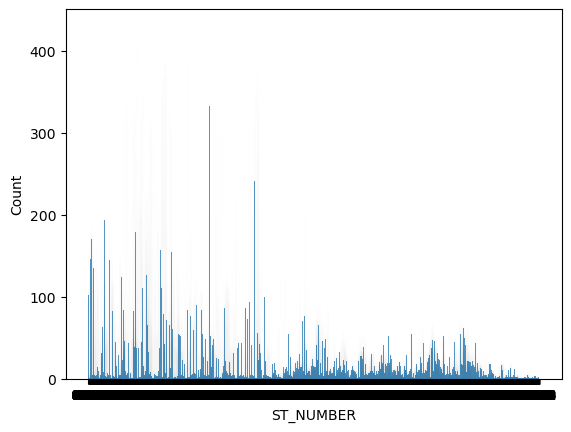

In [30]:
sns.histplot(df["ST_NUMBER"], bins=30)
plt.show()

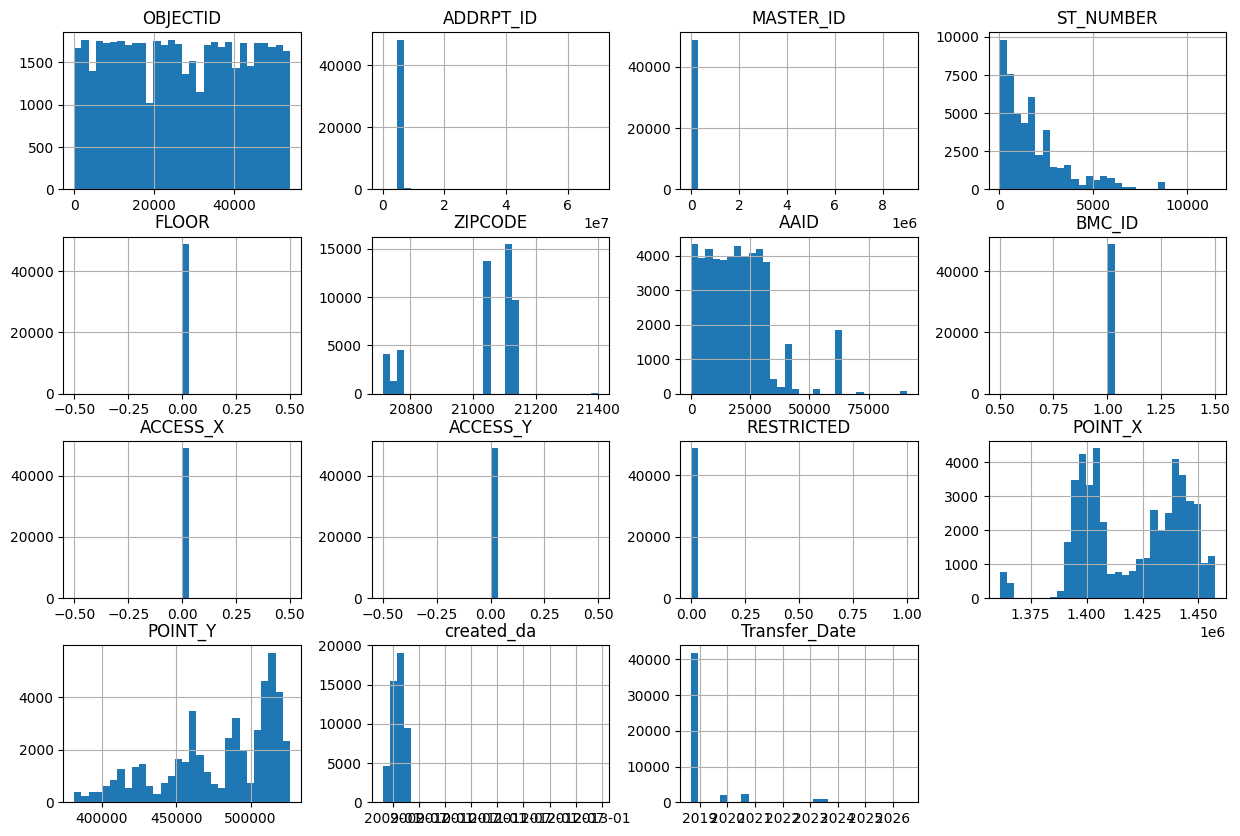

In [34]:
df.hist(figsize=(15,10), bins=30)
plt.show()

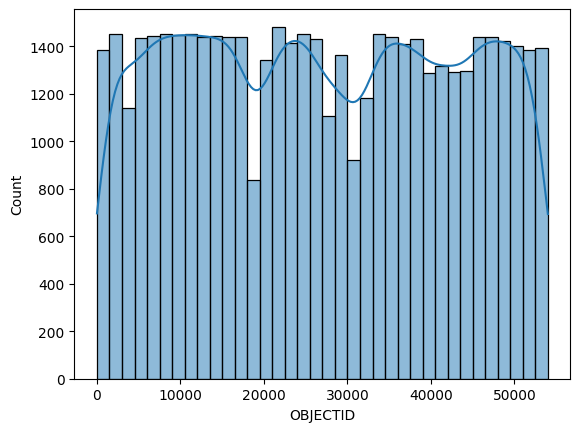

In [36]:
sns.histplot(df["OBJECTID"], kde=True)
plt.show()

In [42]:
df["FLOOR"].value_counts()

FLOOR
0    48880
Name: count, dtype: int64

In [43]:
df["ZIPCODE"].value_counts()

ZIPCODE
21146    8331
21113    8210
21037    7794
21114    7278
21054    3383
21035    2560
20764    1839
20711    1394
21140    1323
20724    1223
20733    1139
20751     988
20776     872
20778     739
20779     551
20714     395
20754     303
20758     289
20765     202
21401      34
20736      25
21032       4
21108       2
21012       1
21144       1
Name: count, dtype: int64

<Axes: xlabel='ZIPCODE'>

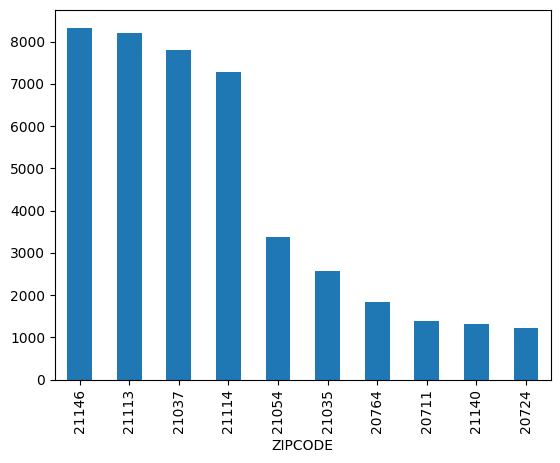

In [44]:
df["ZIPCODE"].value_counts().head(10).plot(kind="bar")

In [46]:
df["RESTRICTED"].value_counts()

RESTRICTED
0    48857
1       23
Name: count, dtype: int64

<Axes: xlabel='RESTRICTED', ylabel='count'>

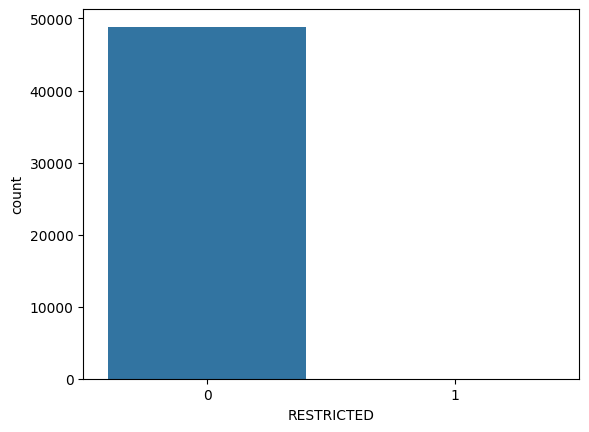

In [48]:
sns.countplot(data=df, x="RESTRICTED")

In [50]:
df["created_da"]= pd.to_datetime(df["created_da"])

In [51]:
df["year"] = df["created_da"].dt.year

In [52]:
df["Month"] = df["created_da"].dt.month_name()

<Axes: xlabel='year'>

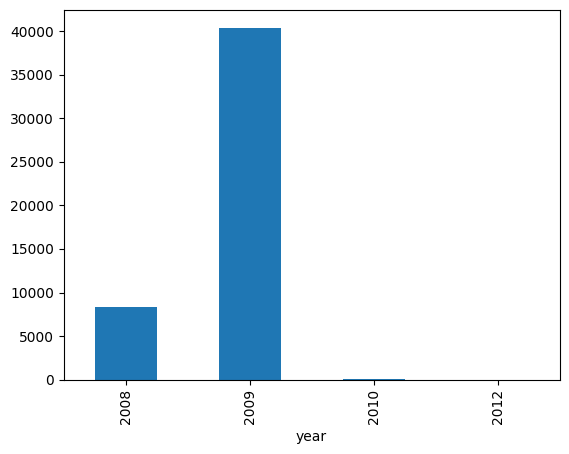

In [53]:
df["year"].value_counts().sort_index().plot(kind="bar")

In [58]:
df["Transfer_Date"].value_counts().sort_index()

Transfer_Date
2018-09-06        2
2018-09-11    41711
2018-09-13       41
2018-09-17        3
2018-09-18       24
              ...  
2026-03-13        1
2026-03-25        4
2026-03-30        1
2026-05-05        1
2026-07-06        1
Name: count, Length: 260, dtype: int64

In [59]:
df["Transfer_Date"] = pd.to_datetime(df["Transfer_Date"])

<Axes: xlabel='Transfer_Date'>

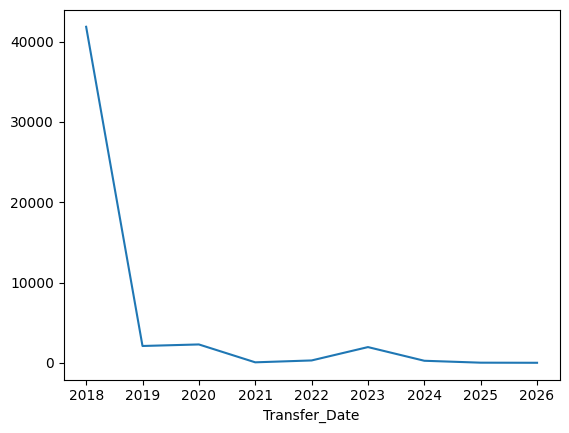

In [60]:
df["Transfer_Date"].dt.year.value_counts().sort_index().plot()

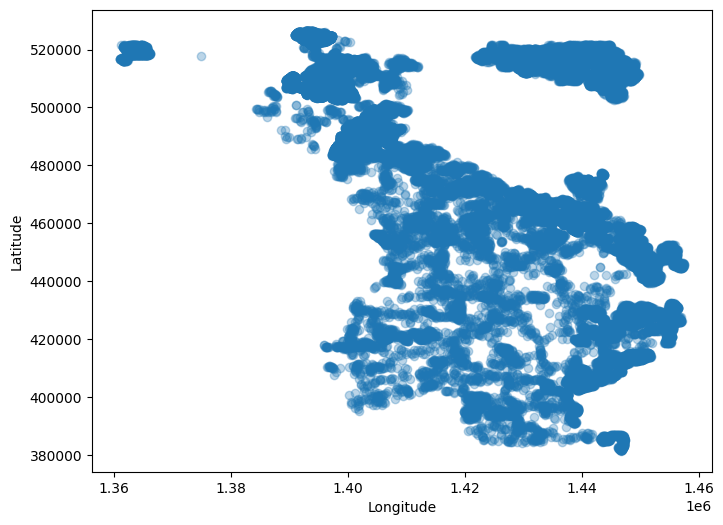

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(df["POINT_X"],
            df["POINT_Y"],
            alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [55]:
df[["ACCESS_X","ACCESS_Y","POINT_X","POINT_Y"]].describe()

,ACCESS_X,ACCESS_Y,POINT_X,POINT_Y
count,48880.0,48880.0,4.888000e+04,48880.000000
mean,0.0,0.0,1.420615e+06,479273.088465
std,0.0,0.0,2.230674e+04,37263.608406
min,0.0,0.0,1.361096e+06,381414.369313
25%,0.0,0.0,1.400845e+06,455241.477155
50%,0.0,0.0,1.423768e+06,489603.527115
75%,0.0,0.0,1.440849e+06,511995.718140
max,0.0,0.0,1.457465e+06,526504.639500


In [62]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.isnull().sum().sort_values(ascending=False)

OBJECTID         0
ADDRPT_ID        0
MASTER_ID        0
PT_TYPE          0
FULL_ADDRE       0
ST_NUMBER        0
ST_NUMSUFF       0
ST_PREFIXD       0
ST_NAME          0
ST_TYPE          0
ST_SUFFIXD       0
BLDG_NAME        0
SOURCE           0
CITY_NAME        0
UNIT_TYPE        0
UNITNUM          0
FLOOR            0
UNIT_ADDR        0
SUB_ADDR         0
BUS_NAME         0
AA_POI           0
ZIPCODE          0
AAID             0
AA_CP            0
BMC_ID           0
ACCESS_X         0
ACCESS_Y         0
BLDG_CODE        0
BLDG_ID          0
RESTRICTED       0
CAD_ST_TYP       0
CAD_ADDR         0
COMMENTS         0
POINT_X          0
POINT_Y          0
STRUC_TYPE       0
GlobalID         0
created_us       0
created_da       0
last_edite       0
Transfer_Date    0
year             0
Month            0
dtype: int64

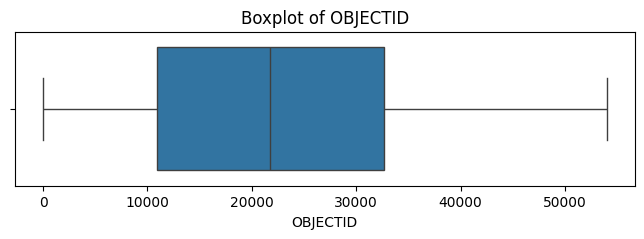

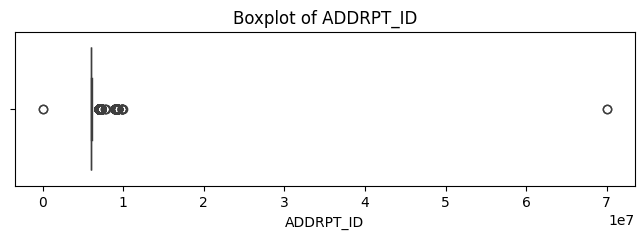

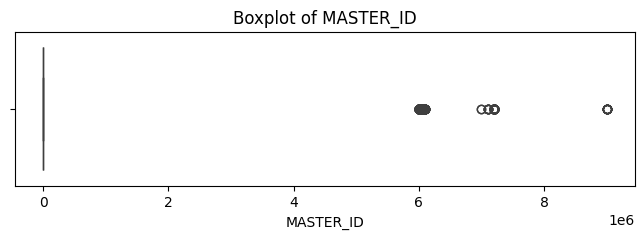

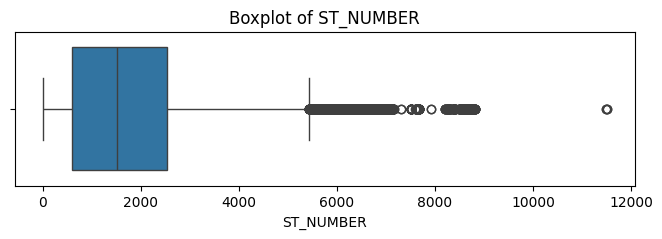

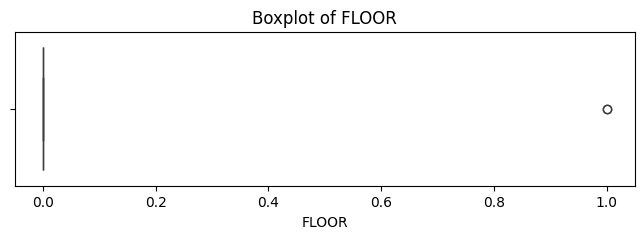

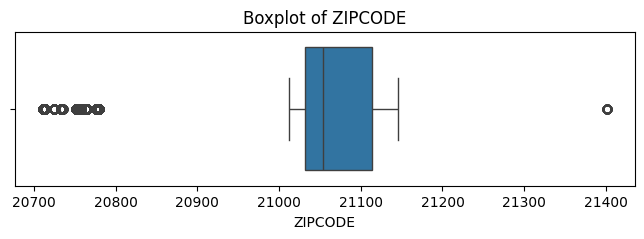

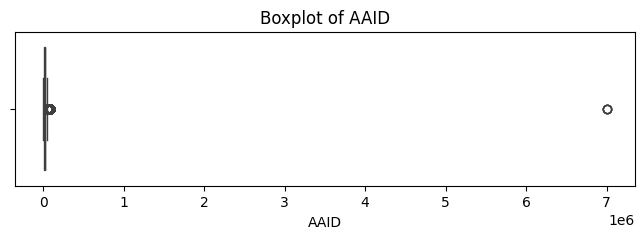

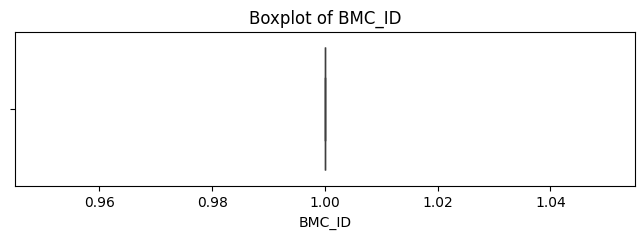

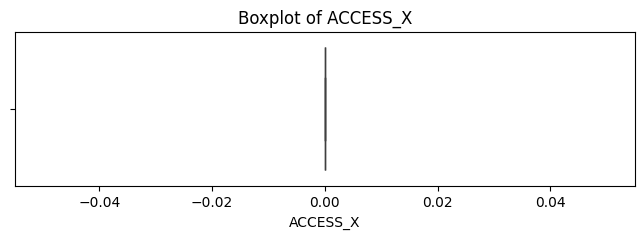

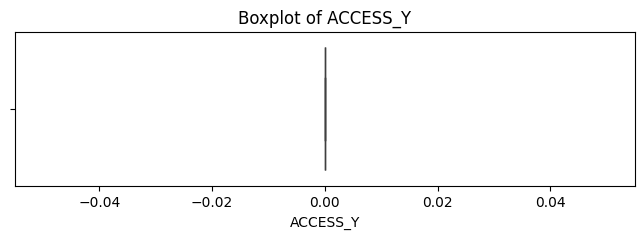

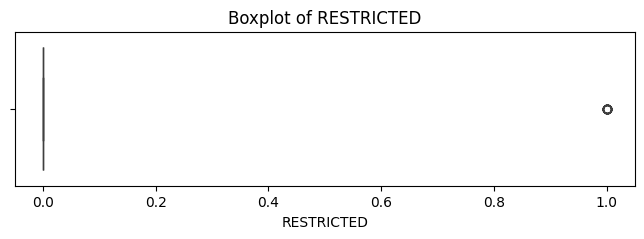

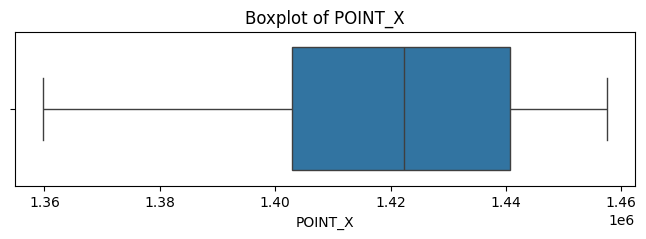

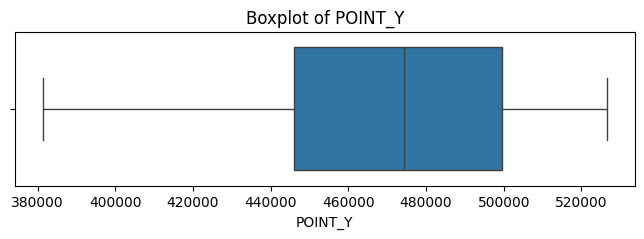

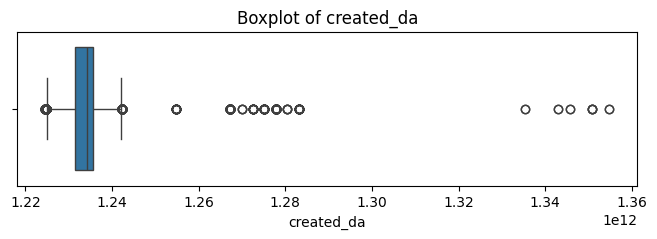

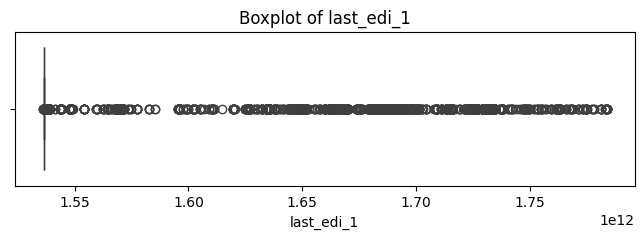

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns 

for col in numeric_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<Axes: >

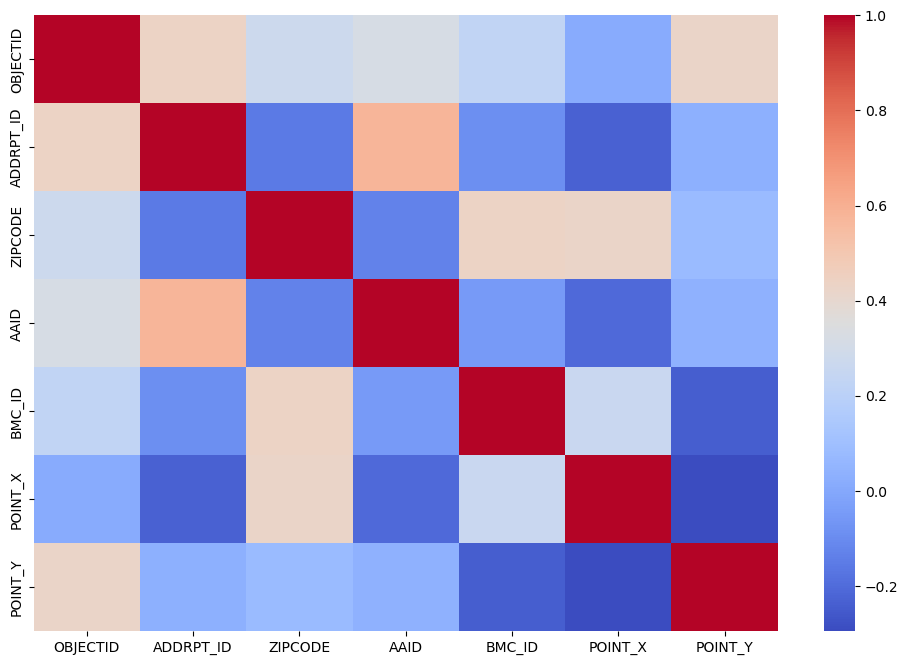

In [74]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))

sns.heatmap(numeric.corr(),
            cmap="coolwarm")

# *phase 4:Outputs & Deliverables*
##### * Cleaned all missing values (Nulls) to reach 100% clean data.
##### * Investigated and fixed the "zero" values issue in the dataset , then Removed useless columns
##### * Visualized the cleaned data on a spatial map to ensure its geographic integrity 
##### * saved the final clean data into ( final_cleaned_data.csv)
##### * created a statistical summary table inside the code.
##### * Exported the summary automaticlly into an file called----> (executive_summary.txt)


In [35]:
df.shape

(186316, 41)

In [36]:
len(df)

186316

In [37]:
df.columns

Index(['OBJECTID', 'ADDRPT_ID', 'MASTER_ID', 'PT_TYPE', 'FULL_ADDRE',
       'ST_NUMBER', 'ST_NUMSUFF', 'ST_PREFIXD', 'ST_NAME', 'ST_TYPE',
       'ST_SUFFIXD', 'BLDG_NAME', 'SOURCE', 'CITY_NAME', 'UNIT_TYPE',
       'UNITNUM', 'FLOOR', 'UNIT_ADDR', 'SUB_ADDR', 'BUS_NAME', 'AA_POI',
       'ZIPCODE', 'AAID', 'AA_CP', 'BMC_ID', 'ACCESS_X', 'ACCESS_Y',
       'BLDG_CODE', 'BLDG_ID', 'RESTRICTED', 'CAD_ST_TYP', 'CAD_ADDR',
       'COMMENTS', 'POINT_X', 'POINT_Y', 'STRUC_TYPE', 'GlobalID',
       'created_us', 'created_da', 'last_edite', 'Transfer_Date'],
      dtype='object')

In [33]:
#Check for duplicate rows in the final data
df.duplicated().sum()

np.int64(0)

In [34]:
#Check for missing values in GIS coordinates
df[['POINT_X', 'POINT_Y']].isnull().sum()

POINT_X    0
POINT_Y    0
dtype: int64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186316 entries, 0 to 215461
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OBJECTID       186316 non-null  int64         
 1   ADDRPT_ID      186316 non-null  int64         
 2   MASTER_ID      186316 non-null  int64         
 3   PT_TYPE        186316 non-null  object        
 4   FULL_ADDRE     186316 non-null  object        
 5   ST_NUMBER      186316 non-null  object        
 6   ST_NUMSUFF     186316 non-null  object        
 7   ST_PREFIXD     186316 non-null  object        
 8   ST_NAME        186316 non-null  object        
 9   ST_TYPE        186316 non-null  object        
 10  ST_SUFFIXD     186316 non-null  object        
 11  BLDG_NAME      186316 non-null  object        
 12  SOURCE         186316 non-null  object        
 13  CITY_NAME      186316 non-null  object        
 14  UNIT_TYPE      186316 non-null  object        
 15  UNITN

In [40]:
#Drop the few rows where 'created_da' is missing
df = df.dropna(subset=['created_da'])

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186297 entries, 0 to 215461
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OBJECTID       186297 non-null  int64         
 1   ADDRPT_ID      186297 non-null  int64         
 2   MASTER_ID      186297 non-null  int64         
 3   PT_TYPE        186297 non-null  object        
 4   FULL_ADDRE     186297 non-null  object        
 5   ST_NUMBER      186297 non-null  object        
 6   ST_NUMSUFF     186297 non-null  object        
 7   ST_PREFIXD     186297 non-null  object        
 8   ST_NAME        186297 non-null  object        
 9   ST_TYPE        186297 non-null  object        
 10  ST_SUFFIXD     186297 non-null  object        
 11  BLDG_NAME      186297 non-null  object        
 12  SOURCE         186297 non-null  object        
 13  CITY_NAME      186297 non-null  object        
 14  UNIT_TYPE      186297 non-null  object        
 15  UNITN

In [42]:
df.describe()

,OBJECTID,ADDRPT_ID,MASTER_ID,FLOOR,ZIPCODE,AAID,BMC_ID,ACCESS_X,ACCESS_Y,RESTRICTED,POINT_X,POINT_Y,created_da,Transfer_Date
count,186297.000000,1.862970e+05,1.862970e+05,186297.0,186297.000000,186297.000000,186297.000000,1.862970e+05,186297.000000,186297.000000,1.862970e+05,186297.000000,186297,186297
mean,103430.777339,9.144229e+06,5.847554e+03,0.0,21115.345872,22366.804635,1.057897,6.950079e+01,24.868402,0.001288,1.427193e+06,510373.450780,2009-11-14 08:23:00.659914240,2019-02-12 09:27:41.534002176
min,1.000000,4.212200e+04,0.000000e+00,0.0,20701.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,1.361096e+06,381414.369313,2008-09-30 00:00:00,2018-09-06 00:00:00
25%,51495.000000,1.080447e+06,0.000000e+00,0.0,21060.000000,9700.000000,1.000000,0.000000e+00,0.000000,0.000000,1.407478e+06,488503.389387,2008-12-10 00:00:00,2018-09-11 00:00:00
50%,103081.000000,1.184821e+06,0.000000e+00,0.0,21113.000000,19606.000000,1.000000,0.000000e+00,0.000000,0.000000,1.428915e+06,519145.213930,2009-02-02 00:00:00,2018-09-11 00:00:00
75%,154044.000000,6.050481e+06,0.000000e+00,0.0,21144.000000,29544.000000,1.000000,0.000000e+00,0.000000,0.000000,1.447594e+06,536718.458639,2009-04-21 00:00:00,2018-09-11 00:00:00
max,215462.000000,7.001556e+07,7.000288e+07,0.0,21409.000000,907324.000000,2.000000,1.463883e+06,546247.806000,1.000000,1.482353e+06,571886.985087,2026-07-01 00:00:00,2026-07-09 00:00:00
std,59898.411161,1.843983e+07,4.334255e+05,0.0,163.051864,17635.728300,0.233549,9.999552e+03,3579.999480,0.035869,2.507298e+04,36271.811315,NaN,NaN


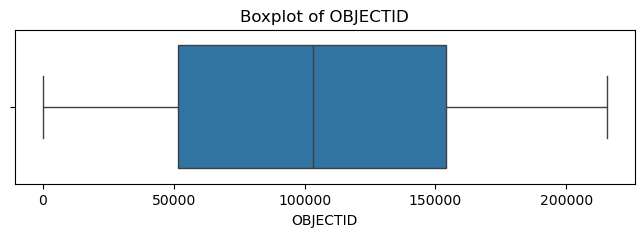

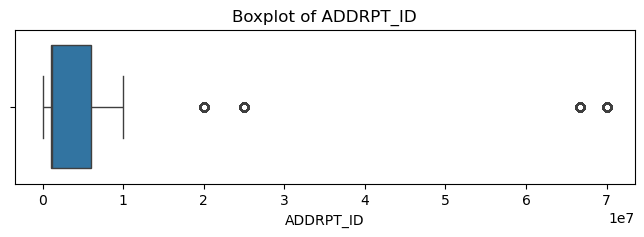

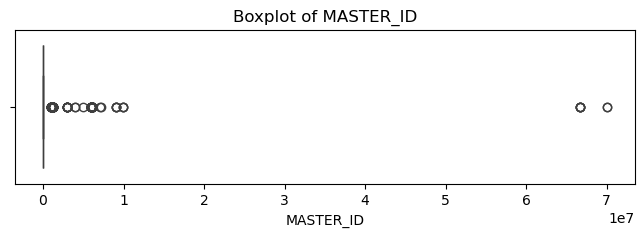

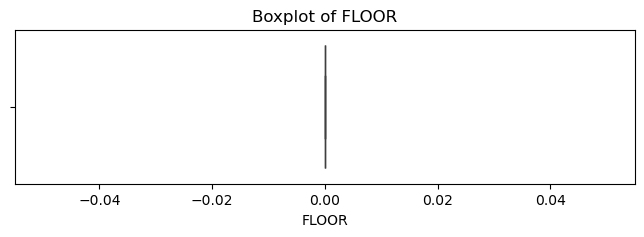

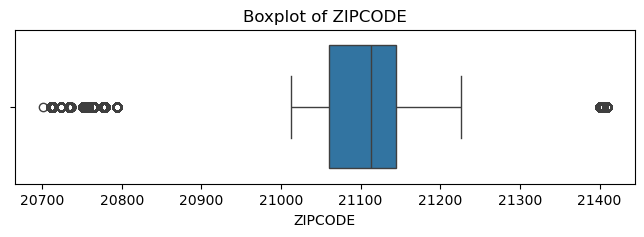

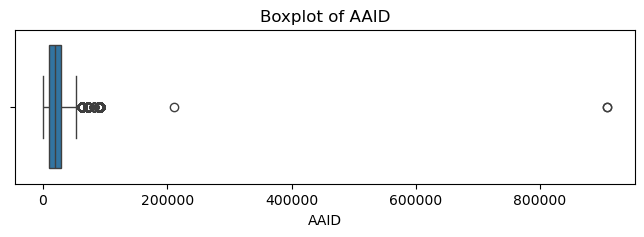

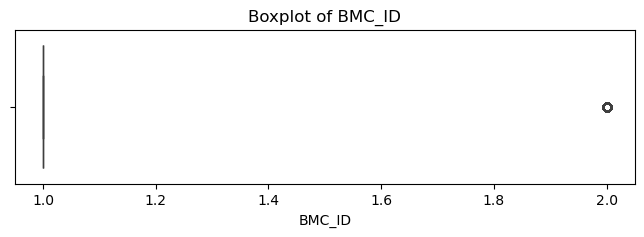

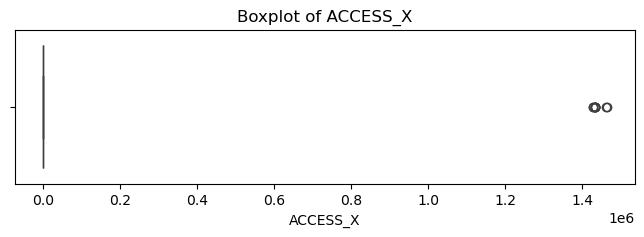

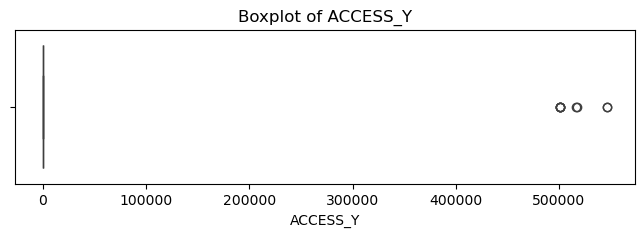

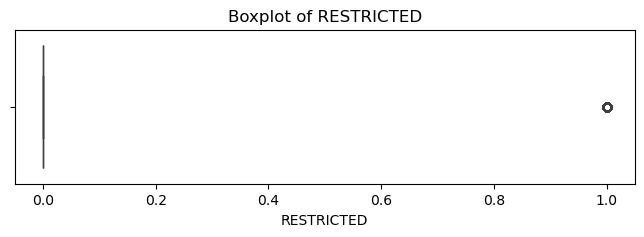

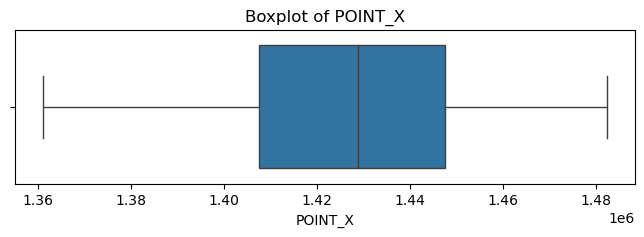

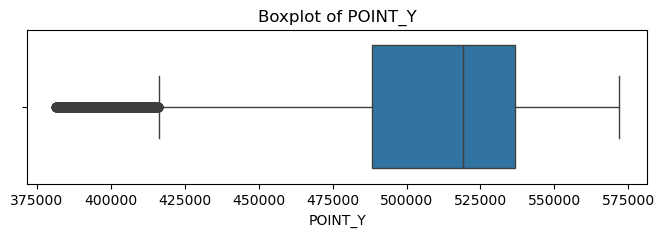

In [47]:
numeric_cols = df.select_dtypes(include=np.number).columns 

for col in numeric_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
#Count zeros in columns
(df == 0).sum()


OBJECTID              0
ADDRPT_ID             0
MASTER_ID        186055
PT_TYPE               0
FULL_ADDRE            0
ST_NUMBER             0
ST_NUMSUFF            0
ST_PREFIXD            0
ST_NAME               0
ST_TYPE               0
ST_SUFFIXD            0
BLDG_NAME             0
SOURCE                0
CITY_NAME             0
UNIT_TYPE             0
UNITNUM               0
FLOOR            186297
UNIT_ADDR             0
SUB_ADDR              0
BUS_NAME              0
AA_POI                0
ZIPCODE               0
AAID                  1
AA_CP                 0
BMC_ID                0
ACCESS_X         186288
ACCESS_Y         186288
BLDG_CODE             0
BLDG_ID               0
RESTRICTED       186057
CAD_ST_TYP            0
CAD_ADDR              0
COMMENTS              0
POINT_X               0
POINT_Y               0
STRUC_TYPE            0
GlobalID              0
created_us            0
created_da            0
last_edite            0
Transfer_Date         0
dtype: int64

In [46]:
df.head()

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,0,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{F789E2B0-0103-484A-A90D-7CF81022BF3E},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,0,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{EDEF7DBF-128B-473E-A28E-751AEB32D0B2},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,0,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{19767F3B-BE84-416D-AA1D-82F7690A6BA7},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,0,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{6EB2A48F-9403-4835-ABB6-F4CBC0034711},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,0,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,0,,,,N,20751,6371,N,1,0.0,0.0,RESIDENTIAL,,0,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{05272E89-016B-46F5-A21C-E28CA8F2E052},,2008-10-24,ITMAGL23,2020-07-27


In [58]:
df.sample(5)

,OBJECTID,ADDRPT_ID,MASTER_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,FLOOR,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,ACCESS_X,ACCESS_Y,BLDG_CODE,BLDG_ID,RESTRICTED,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
134875,134876,1080899,0,ADDRESS,"7933 OAKWOOD RD, 21061",7933,,,OAKWOOD,RD,,,PHYSICALLY VERIFIED IN FIELD,GLEN BURNIE,,,0,,,,N,21061,471,N,1,0.0,0.0,RESIDENTIAL,,0,RD,7933 OAKWOOD RD,,1.420625e+06,534113.161028,SFD,{36976BB5-FB5E-4521-B0AC-2679D27682C6},,2008-11-03,ITVMAN00,2018-09-11
104410,104411,1048906,0,ADDRESS,"121 CAMROSE AVE, 21225",121,,,CAMROSE,AVE,,,PHYSICALLY VERIFIED IN FIELD,BROOKLYN,,,0,,,,N,21225,20517,N,1,0.0,0.0,RESIDENTIAL,,0,AV,121 CAMROSE AV,,1.420581e+06,563762.000024,SFD,{65CD9A1E-BC8A-4824-83D5-8C56604EDD3D},,2008-10-31,ITVMAN00,2018-09-11
14344,14345,6017808,0,ADDRESS,"1608 MIDLAND RD, 21037",1608,,,MIDLAND,RD,,,PHYSICALLY VERIFIED IN FIELD,EDGEWATER,,,0,,,,N,21037,10125,N,1,0.0,0.0,RESIDENTIAL,,0,RD,1608 MIDLAND RD,,1.441393e+06,462095.802438,SFD,{1949CEB2-6ECC-4E95-90D7-40E21D56A3C8},,2009-01-18,ITVMAN00,2018-09-11
51685,51686,6065382,0,ADDRESS,"685 FAIRCASTLE AVE, 21146",685,,,FAIRCASTLE,AVE,,,PHYSICALLY VERIFIED IN FIELD,SEVERNA PARK,,,0,,,,N,21146,24682,N,1,0.0,0.0,RESIDENTIAL,,0,AV,685 FAIRCASTLE AV,,1.423889e+06,518989.681105,SFD,{BFFE8E6B-D90F-4969-A8B4-86710403CBD1},,2009-05-02,ITVMAN00,2018-09-11
60988,60989,6030946,0,ADDRESS,"802 HOLLY DR E, 21409",802,,,HOLLY,DR,E,,PHYSICALLY VERIFIED IN FIELD,ANNAPOLIS,,,0,,,,N,21409,5875,N,1,0.0,0.0,RESIDENTIAL,,0,DR,802 HOLLY DR E,,1.472934e+06,492470.675416,SFD,{81F58CF1-21FE-4DA7-9C02-EB091EC6A879},,2009-07-08,ITVMAN00,2018-09-11


In [ ]:
#check the number of zeros in columns
(df[['FLOOR', 'ACCESS_X', 'ACCESS_Y', 'MASTER_ID', 'RESTRICTED']]==0).sum()


FLOOR         186297
ACCESS_X      186288
ACCESS_Y      186288
MASTER_ID     186055
RESTRICTED    186057
dtype: int64

In [60]:
# Drop columns that are entirely or mostly filled with zeros 
df = df.drop(columns=['FLOOR', 'ACCESS_X', 'ACCESS_Y', 'MASTER_ID', 'RESTRICTED'])

In [61]:
df.head()

,OBJECTID,ADDRPT_ID,PT_TYPE,FULL_ADDRE,ST_NUMBER,ST_NUMSUFF,ST_PREFIXD,ST_NAME,ST_TYPE,ST_SUFFIXD,BLDG_NAME,SOURCE,CITY_NAME,UNIT_TYPE,UNITNUM,UNIT_ADDR,SUB_ADDR,BUS_NAME,AA_POI,ZIPCODE,AAID,AA_CP,BMC_ID,BLDG_CODE,BLDG_ID,CAD_ST_TYP,CAD_ADDR,COMMENTS,POINT_X,POINT_Y,STRUC_TYPE,GlobalID,created_us,created_da,last_edite,Transfer_Date
0,1,6001687,ADDRESS,"625 IRVIN AVE, 20751",625,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,625 IRVIN AV,ADDED PT_TYPE,1.439284e+06,402495.290406,SFD,{F789E2B0-0103-484A-A90D-7CF81022BF3E},,2008-10-24,GIS_AnneArundel,2025-03-13
1,2,6001692,ADDRESS,"626 IRVIN AVE, 20751",626,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,626 IRVIN AV,,1.439212e+06,402767.288550,SFD,{EDEF7DBF-128B-473E-A28E-751AEB32D0B2},,2008-10-24,pzmagl22,2025-02-25
2,3,6001700,ADDRESS,"615 IRVIN AVE, 20751",615,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,615 IRVIN AV,,1.439111e+06,402678.746732,SFD,{19767F3B-BE84-416D-AA1D-82F7690A6BA7},,2008-10-24,ITMAGL23,2020-07-27
3,4,6001704,ADDRESS,"622 IRVIN AVE, 20751",622,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,622 IRVIN AV,,1.439271e+06,402690.877941,SFD,{6EB2A48F-9403-4835-ABB6-F4CBC0034711},,2008-10-24,ITMAGL23,2020-07-27
4,5,6001709,ADDRESS,"624 IRVIN AVE, 20751",624,,,IRVIN,AVE,,,PHYSICALLY VERIFIED IN FIELD,DEALE,,,,,,N,20751,6371,N,1,RESIDENTIAL,,AV,624 IRVIN AV,,1.439239e+06,402729.958244,SFD,{05272E89-016B-46F5-A21C-E28CA8F2E052},,2008-10-24,ITMAGL23,2020-07-27


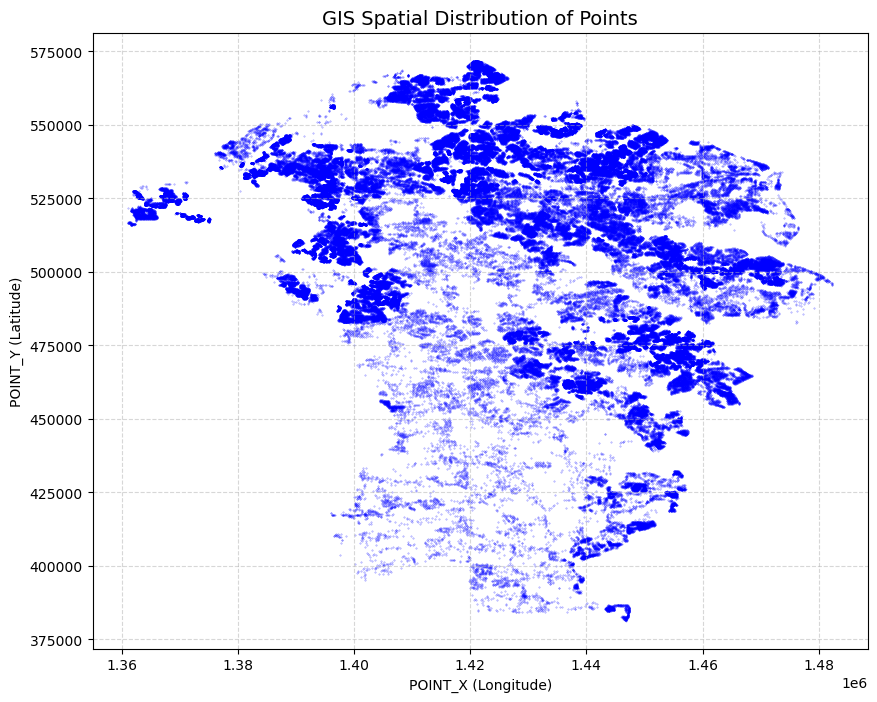

In [64]:
plt.figure(figsize=(10, 8))
plt.scatter(df['POINT_X'], df['POINT_Y'], s=0.1, color='blue', alpha=0.5)
plt.title('GIS Spatial Distribution of Points', fontsize=14)
plt.xlabel('POINT_X (Longitude)')
plt.ylabel('POINT_Y (Latitude)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
#Save the final cleaned dataset to a new CSV file
df.to_csv('final_cleaned_Anne_Arundel.csv', index=False)

In [66]:
print("==================================================")
print("             EXECUTIVE SUMMARY REPORT             ")
print("==================================================")

# 1. Total number of records (Rows and Columns)
print(f"Total Cleaned Records: {df.shape[0]} rows")
print(f"Total Useful Features: {df.shape[1]} columns")
print("-" * 50)

# 2. Statistical Summary for numerical columns
print("Descriptive Statistics for Key Numerical Data:")
print(df.describe().round(2))
print("-" * 50)

# 3. Check for any remaining missing values (Verification)
print("Missing values remaining in the dataset:")
print(df.isnull().sum().sum())
print("==================================================")

             EXECUTIVE SUMMARY REPORT             
Total Cleaned Records: 186297 rows
Total Useful Features: 36 columns
--------------------------------------------------
Descriptive Statistics for Key Numerical Data:
        OBJECTID    ADDRPT_ID    ZIPCODE       AAID     BMC_ID     POINT_X  \
count  186297.00    186297.00  186297.00  186297.00  186297.00   186297.00   
mean   103430.78   9144228.61   21115.35   22366.80       1.06  1427193.11   
min         1.00     42122.00   20701.00       0.00       1.00  1361095.62   
25%     51495.00   1080447.00   21060.00    9700.00       1.00  1407478.35   
50%    103081.00   1184821.00   21113.00   19606.00       1.00  1428915.22   
75%    154044.00   6050481.00   21144.00   29544.00       1.00  1447593.59   
max    215462.00  70015556.00   21409.00  907324.00       2.00  1482353.34   
std     59898.41  18439833.84     163.05   17635.73       0.23    25072.98   

         POINT_Y                     created_da                  Transfer_Date 

In [73]:
with open ('executive_summary.txt' , 'w' , encoding='utf-8 ') as f:
    f.write('========================================\n' )
    f.write('        EXECUTIVE SUMMARY REPORT            \n')
    f.write('========================================\n \n')

    # dataset dimentions
    f.write(f'Total Cleaned Records : {df.shape[0]:,} rows \n')
    f.write(f'Total Useful features : {df.shape[1]} columns \n')
    f.write ( '-' * 50 + '\n') 
    # null values check   
    remaining_nulls=df.isnull().sum().sum()
    f.write(f'Remaining missing values : { remaining_nulls} ( data is 100% clean. )\n')
    f.write('-'*50 + '\n \n ')
    # descriptive statistics table 
    f.write( 'Descriptive Statistics for key Numerical feature :\n')
    f.write ( df.describe() .to_string())
    f.write('\n \n =============================================')
    print('SUCESSSSSS')

SUCESSSSSS
